modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\user\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--snunlp--KR-SBERT-V40K-klueNLI-augSTS. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

문장 임베딩 추출 중... (시간이 다소 걸릴 수 있습니다)


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

차원 축소 실행 중...


c:\Users\user\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


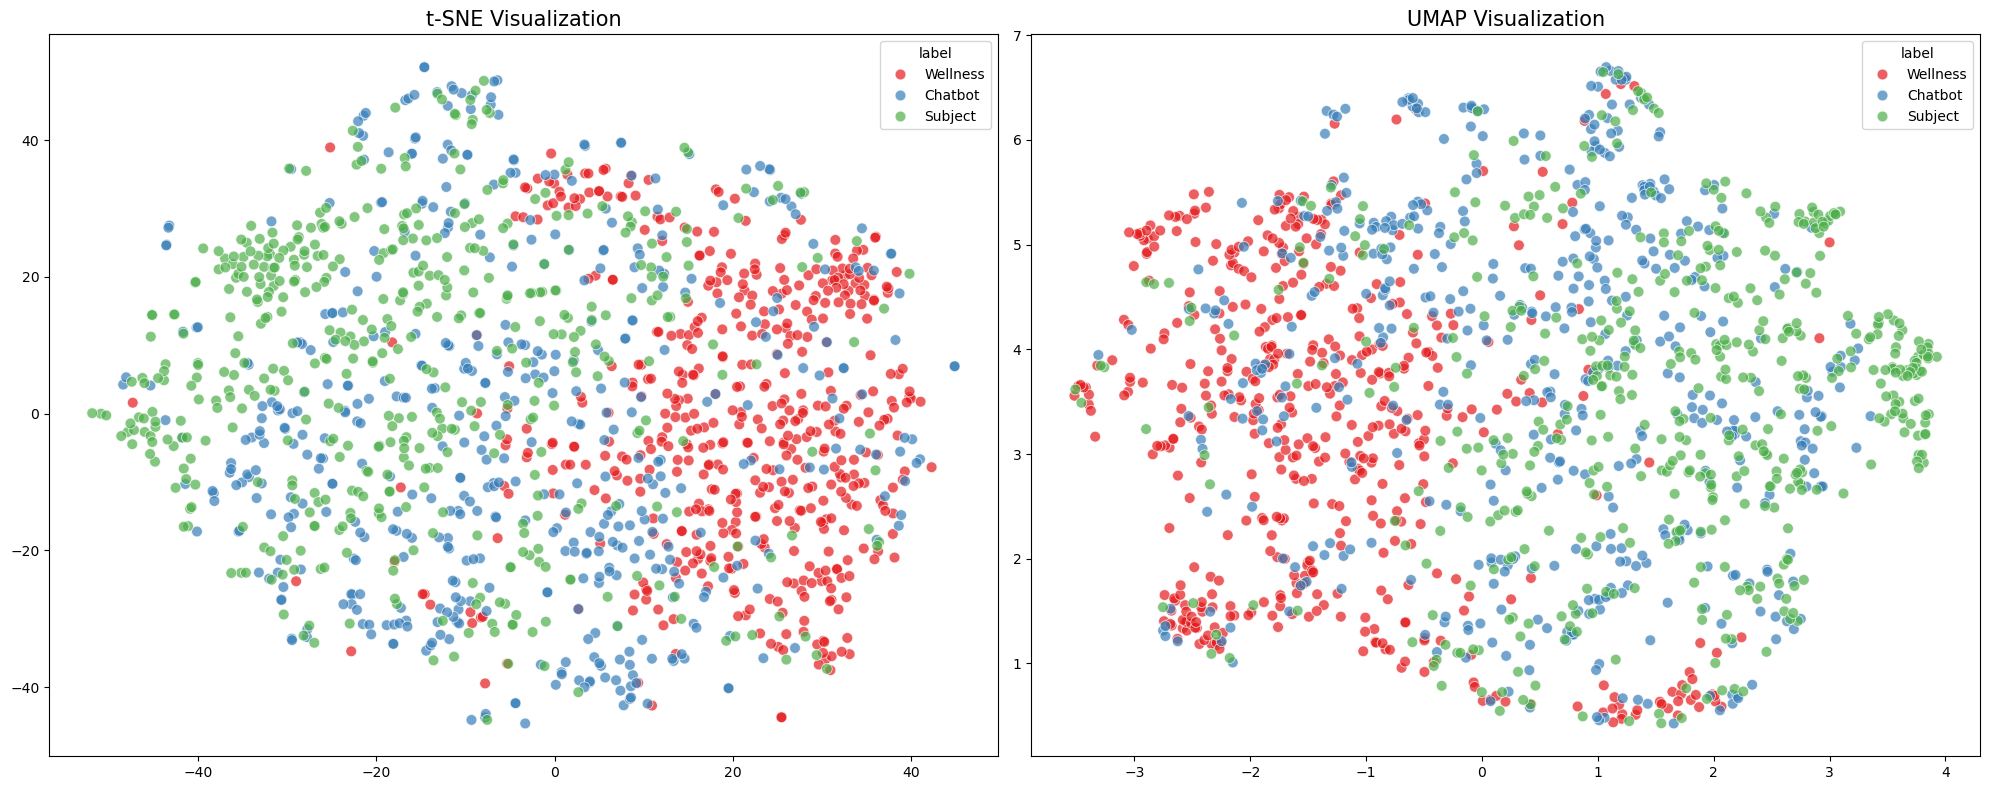

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from umap import UMAP

# 1. 모델 로드 (한국어 성능이 우수한 SBERT 모델)
model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')

# 2. 데이터 로드 및 샘플링
# 데이터가 너무 많으면 시각화가 지저분해지므로 각 데이터셋에서 500개씩 샘플링합니다.
def load_and_sample(filename, label, n=500):
    df = pd.read_csv(filename)
    sampled_df = df.sample(n=min(len(df), n), random_state=42)
    sampled_df['label'] = label
    return sampled_df[['utterance', 'label']]

df1 = load_and_sample('cleaned_wellness.csv', 'Wellness')
df2 = load_and_sample('cleaned_chatbot.csv', 'Chatbot')
df3 = load_and_sample('cleaned_subject.csv', 'Subject')

combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# 3. 문장 임베딩 추출
print("문장 임베딩 추출 중... (시간이 다소 걸릴 수 있습니다)")
embeddings = model.encode(combined_df['utterance'].tolist(), show_progress_bar=True)

# 4. 차원 축소 실행 (t-SNE & UMAP)
print("차원 축소 실행 중...")
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# UMAP
umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = umap_model.fit_transform(embeddings)

# 5. 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# t-SNE Plot
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], 
                hue=combined_df['label'], palette='Set1', ax=ax1, s=60, alpha=0.7)
ax1.set_title('t-SNE Visualization', fontsize=15)

# UMAP Plot
sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1], 
                hue=combined_df['label'], palette='Set1', ax=ax2, s=60, alpha=0.7)
ax2.set_title('UMAP Visualization', fontsize=15)

plt.tight_layout()
plt.show()